In [1]:

# from datasets import load_dataset, Image
# from PIL import Image as PILImage
# from io import BytesIO
# from pathlib import Path
# from tqdm import tqdm
# import pandas as pd

# train_ds = load_dataset(
#     "ComplexDataLab/OpenFake",
#     "core",
#     split="train",
#     streaming=True
# )

# train_ds = train_ds.cast_column(
#     "image",
#     Image(decode=False)
# )

# OUT = Path("/kaggle/working/openfake_subset")
# (OUT / "real").mkdir(parents=True, exist_ok=True)
# (OUT / "fake").mkdir(parents=True, exist_ok=True)

# TARGET = 10000

# counts = {"real": 0, "fake": 0}
# metadata = []

# for sample in tqdm(train_ds):

#     label = sample["label"]

#     if label not in ["real", "fake"]:
#         continue

#     if counts[label] >= TARGET:
#         continue

#     try:
#         img_data = sample["image"]

#         if img_data["bytes"] is not None:
#             img = PILImage.open(BytesIO(img_data["bytes"])).convert("RGB")
#         else:
#             img = PILImage.open(img_data["path"]).convert("RGB")

#         filename = f"{label}_{counts[label]:06d}.jpg"
#         save_path = OUT / label / filename
#         img = img.resize((384, 384)) 
#         img.save(save_path, quality=90)

#         metadata.append({
#             "path": str(save_path),
#             "label": label,
#             "model": sample["model"],
#             "prompt": sample["prompt"],
#             "type": sample["type"],
#             "release_date": sample["release_date"]
#         })

#         counts[label] += 1

#         if counts["real"] == TARGET and counts["fake"] == TARGET:
#             break

#     except Exception:
#         continue

# pd.DataFrame(metadata).to_csv(OUT / "metadata.csv", index=False)

# print(counts)


In [2]:
#!zip -r /kaggle/working/openfake_subset1.zip /kaggle/working/openfake_subset

In [22]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from transformers import AutoProcessor, AutoModel
from tqdm import tqdm
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [4]:
DATA_ROOT = "/kaggle/input/datasets/nishant2015/openfake50k/kaggle/working/openfake_subset"

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [6]:
def apply_augmentations(image):
    image = image.convert("RGB")

    if random.random() < 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)

    if random.random() < 0.4:
        w, h = image.size
        scale = random.uniform(0.5, 1.0)
        nw, nh = int(w * scale), int(h * scale)
        left = random.randint(0, max(0, w - nw))
        top = random.randint(0, max(0, h - nh))
        image = image.crop((left, top, left + nw, top + nh))
        image = image.resize((w, h), Image.BICUBIC)

    if random.random() < 0.5:
        buffer = io.BytesIO()
        quality = random.randint(30, 95)
        image.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        image = Image.open(buffer).convert("RGB")

    if random.random() < 0.3:
        image = image.filter(
            ImageFilter.GaussianBlur(radius=random.uniform(0.1, 2.0))
        )

    if random.random() < 0.3:
        arr = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(0, random.uniform(0.0, 0.05), arr.shape)
        arr = np.clip(arr + noise, 0, 1)
        image = Image.fromarray((arr * 255).astype(np.uint8))

    if random.random() < 0.4:
        image = ImageEnhance.Brightness(image).enhance(random.uniform(0.7, 1.3))
        image = ImageEnhance.Contrast(image).enhance(random.uniform(0.7, 1.3))
        image = ImageEnhance.Color(image).enhance(random.uniform(0.7, 1.3))

    return image

In [7]:
class FolderBinaryDataset(Dataset):
    def __init__(self, paths, labels, processor, augment=False):
        self.paths = paths
        self.labels = labels
        self.processor = processor
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")

        if self.augment:
            image = apply_augmentations(image)

        inputs = self.processor(
            images=image,
            return_tensors="pt"
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [8]:
root = Path(DATA_ROOT)

real_paths = list((root / "real").glob("*.jpg"))
fake_paths = list((root / "fake").glob("*.jpg"))

paths = real_paths + fake_paths
labels = [0] * len(real_paths) + [1] * len(fake_paths)

print("Real:", len(real_paths))
print("Fake:", len(fake_paths))
print("Total:", len(paths))

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Real: 25000
Fake: 25000
Total: 50000
Train: 40000
Val: 5000
Test: 5000


In [9]:
MODEL_NAME = "google/siglip-base-patch16-224"

processor = AutoProcessor.from_pretrained(MODEL_NAME)

train_dataset = FolderBinaryDataset(
    train_paths,
    train_labels,
    processor,
    augment=True
)

val_dataset = FolderBinaryDataset(
    val_paths,
    val_labels,
    processor,
    augment=False
)

test_dataset = FolderBinaryDataset(
    test_paths,
    test_labels,
    processor,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
class SigLIPDetector(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(model_name)

        hidden_size = self.backbone.config.vision_config.hidden_size

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 2)
        )

    def forward(self, pixel_values):
        outputs = self.backbone.vision_model(pixel_values=pixel_values)
        features = outputs.pooler_output
        logits = self.classifier(features)
        return logits

In [23]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            logits = model(pixel_values)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Probability of Fake class (class 1)
            all_probs.extend(probs[:, 1].cpu().numpy())

    avg_loss = total_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    # ======================
    # Confusion Matrix
    # ======================

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    plt.tight_layout()

    plt.savefig("confusion_matrix.png", dpi=300)
    plt.show()

    # ======================
    # ROC Curve
    # ======================

    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig("roc_curve.png", dpi=300)
    plt.show()

    print(f"ROC-AUC: {roc_auc:.4f}")

    return avg_loss, acc, f1, roc_auc

In [12]:

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SigLIPDetector(MODEL_NAME).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

EPOCHS = 5
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(pixel_values)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_acc = accuracy_score(all_labels, all_preds)
    train_f1 = f1_score(all_labels, all_preds)

    val_loss, val_acc, val_f1 = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print("=" * 60)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Train F1  : {train_f1:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")
    print(f"Val F1    : {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/kaggle/working/best_openfake_siglip.pth")
        print("✓ Best model saved")
   

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

100%|██████████| 1250/1250 [23:29<00:00,  1.13s/it]


Epoch 1/5
Train Loss: 0.3367
Train Acc : 0.8469
Train F1  : 0.8458
Val Loss  : 0.1885
Val Acc   : 0.9268
Val F1    : 0.9247
✓ Best model saved


100%|██████████| 1250/1250 [23:37<00:00,  1.13s/it]


...

Epoch 3/5
Train Loss: 0.1299
Train Acc : 0.9485
Train F1  : 0.9483
Val Loss  : 0.1543
Val Acc   : 0.9422
Val F1    : 0.9420
✓ Best model saved


100%|██████████| 1250/1250 [23:38<00:00,  1.13s/it]


Epoch 4/5
Train Loss: 0.0971
Train Acc : 0.9632
Train F1  : 0.9631
Val Loss  : 0.2177
Val Acc   : 0.9288
Val F1    : 0.9316


100%|██████████| 1250/1250 [23:37<00:00,  1.13s/it]


Epoch 5/5
Train Loss: 0.0834
Train Acc : 0.9675
Train F1  : 0.9674
Val Loss  : 0.1927
Val Acc   : 0.9350
Val F1    : 0.9361


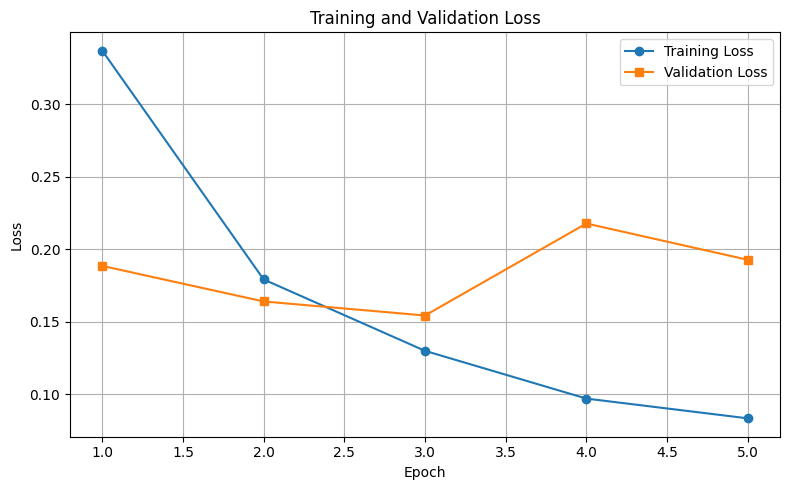

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    range(1, len(val_losses)+1),
    val_losses,
    marker='s',
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

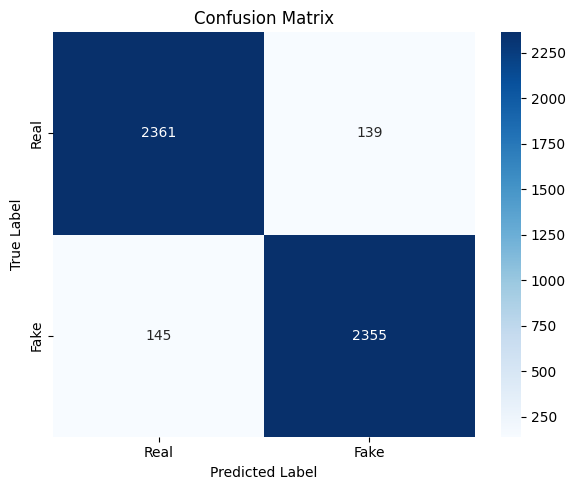

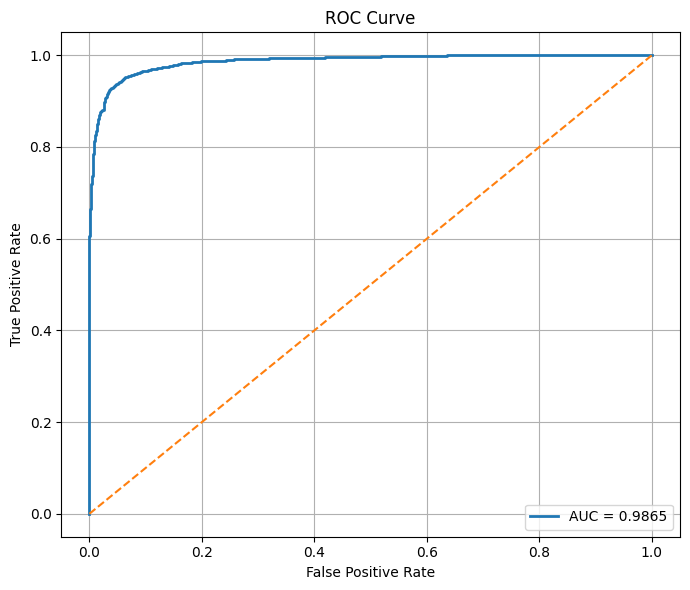

ROC-AUC: 0.9865
Test Loss: 0.15242084022018182
Test Acc : 0.9432
Test F1  : 0.9431317581097317
Roc auc score : 0.98653136


In [25]:
model.load_state_dict(
    torch.load("/kaggle/working/best_openfake_siglip.pth", map_location=device)
)

test_loss, test_acc, test_f1, roc_auc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", test_loss)
print("Test Acc :", test_acc)
print("Test F1  :", test_f1)
print("Roc auc score :",roc_auc)

In [26]:
from pathlib import Path
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import torch
from tqdm import tqdm

REAL_DIR = Path("/kaggle/input/datasets/hiddenplant/sut-project/Super_GenAI_Dataset/Real")
FAKE_DIR = Path("/kaggle/input/datasets/hiddenplant/sut-project/Super_GenAI_Dataset/Fake")

def evaluate_super_genai(
    model,
    processor,
    device,
    real_dir,
    fake_dir
):

    model.eval()

    image_paths = []
    labels = []

    for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:

        real_files = list(real_dir.rglob(ext))
        fake_files = list(fake_dir.rglob(ext))

        image_paths.extend(real_files)
        labels.extend([0] * len(real_files))

        image_paths.extend(fake_files)
        labels.extend([1] * len(fake_files))

    print("Total images:", len(image_paths))

    preds = []
    fake_probs = []

    with torch.no_grad():

        for img_path in tqdm(image_paths):

            try:
                image = Image.open(img_path).convert("RGB")

                inputs = processor(
                    images=image,
                    return_tensors="pt"
                )

                pixel_values = inputs["pixel_values"].to(device)

                logits = model(pixel_values)

                probs = torch.softmax(
                    logits,
                    dim=1
                )[0]

                fake_prob = probs[1].item()

                pred = torch.argmax(
                    probs,
                    dim=0
                ).item()

                preds.append(pred)
                fake_probs.append(fake_prob)

            except Exception:
                preds.append(1)
                fake_probs.append(1.0)

    acc = accuracy_score(labels, preds)

    precision = precision_score(
        labels,
        preds
    )

    recall = recall_score(
        labels,
        preds
    )

    f1 = f1_score(
        labels,
        preds
    )

    cm = confusion_matrix(
        labels,
        preds
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        fake_probs
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    print("\n")
    print("=" * 50)

    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc_auc)

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(
        classification_report(
            labels,
            preds,
            target_names=[
                "Real",
                "Fake"
            ]
        )
    )

    # ============================
    # Confusion Matrix Plot
    # ============================

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Super GenAI Dataset")

    plt.tight_layout()
    plt.savefig(
        "super_genai_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # ============================
    # ROC Curve Plot
    # ============================

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Super GenAI Dataset")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(
        "super_genai_roc_curve.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return acc, precision, recall, f1, roc_auc

Total images: 9504


100%|██████████| 9504/9504 [08:42<00:00, 18.17it/s]




Accuracy : 0.8880471380471381
Precision: 0.9314459522695367
Recall   : 0.8377525252525253
F1 Score : 0.8821183248393529
ROC-AUC  : 0.9524751318601277

Confusion Matrix
[[4459  293]
 [ 771 3981]]

Classification Report
              precision    recall  f1-score   support

        Real       0.85      0.94      0.89      4752
        Fake       0.93      0.84      0.88      4752

    accuracy                           0.89      9504
   macro avg       0.89      0.89      0.89      9504
weighted avg       0.89      0.89      0.89      9504



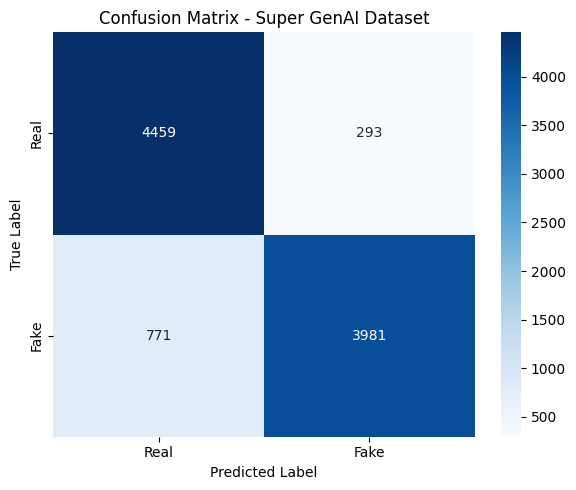

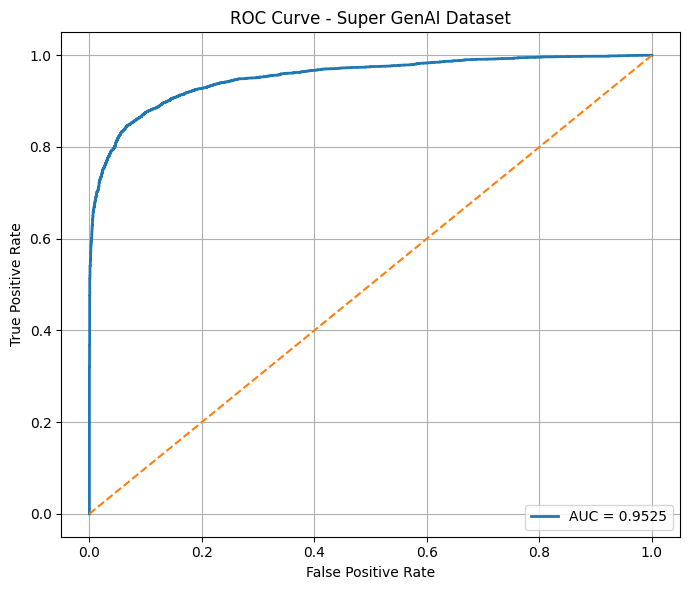

In [27]:
acc,  precision, recall, f1, roc_auc= evaluate_super_genai(
    model,
    processor,
    device,
    REAL_DIR,
    FAKE_DIR
)